In [1]:
import pandas as pd
import numpy as np


In [2]:
import sys
sys.path.append("/home/pcsl/Documents/plecs/sepic/plecs_python_auto/AImodel")
import model_create as mc
from keras import optimizers

# model_ripple = mc.build_residual_mlp_ripple()
model_ripple = mc.build_random_forest()
model_mos_loss = mc.build_residual(input_dim=4, output_dim=2, model_name="mos_loss")
model_dio_loss = mc.build_residual(input_dim=4, output_dim=1, model_name="dio_loss")
model_leakage = mc.build_residual(input_dim=4, output_dim=1, model_name="leakage_current")
model_ESR_loss = mc.build_residual(input_dim=4, output_dim=4, model_name="ESR_loss")

2026-04-26 20:04:13.133271: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777201453.179627    7471 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777201453.194555    7471 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-26 20:04:13.305572: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777201455.144586    7471 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 59

In [3]:

df = pd.read_csv('/home/pcsl/Documents/plecs/sepic/plecs_python_auto/out/sepic_data/inner_loop/ripple_results.csv')
print(f"행 개수 :  {len(df)}")


행 개수 :  9701


In [4]:
from sklearn.preprocessing import LabelEncoder


df = df[df["mosfet_cond_loss"] <= 10000] # maximum limitation

X = df[['L1', 'L2', 'C1', 'C2']].values
y_ripple  = df[['i_L1_ripple_rate', 'V_out_ripple_rate']].values
y_leakage = df[['leakage_rms']].values
y_mos_loss = df[['mosfet_cond_loss', 'mosfet_switch_loss']].values
y_dio_loss = df[['diode_cond_loss']].values
y_ESR_loss = df[['L1_ESR_loss', 'L2_ESR_loss', 'C1_ESR_loss', 'C2_ESR_loss']].values

# CCM, DCM Mode 분리 model

In [5]:

splits = mc.split_data(X, y_ripple, y_mos_loss, y_dio_loss, y_leakage, y_ESR_loss)

X_train, X_val, X_test = splits[0]
y_ripple_train, y_ripple_val, y_ripple_test = splits[1]
y_mos_loss_train, y_mos_loss_val, y_mos_loss_test = splits[2]
y_dio_loss_train, y_dio_loss_val, y_dio_loss_test = splits[3]
y_leakage_train, y_leakage_val, y_leakage_test = splits[4]
y_ESR_loss_train, y_ESR_loss_val, y_ESR_loss_test = splits[5]

## Scaler

In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# HS용
y_ripple_mmscaler  = MinMaxScaler()
y_leakage_mmscaler = MinMaxScaler()

y_ripple_mmscaler.fit_transform(y_ripple)

# 학습용
X_train, X_val, X_test, x_scaler = mc.scale_data(
    X_train, X_val, X_test,
    scaler = MinMaxScaler()
)

#ripple
y_ripple_train, y_ripple_val, y_ripple_test, y_ripple_scaler = mc.scale_data(
    y_ripple_train, y_ripple_val, y_ripple_test,
    scaler = StandardScaler()
)

# mosfet loss
y_mos_loss_train, y_mos_loss_val, y_mos_loss_test, y_mos_loss_scaler = mc.scale_data(
    y_mos_loss_train, y_mos_loss_val, y_mos_loss_test,
    scaler = StandardScaler()
)

# diode loss 
y_dio_loss_train, y_dio_loss_val, y_dio_loss_test, y_dio_loss_scaler = mc.scale_data(
    y_dio_loss_train, y_dio_loss_val, y_dio_loss_test,
    scaler = StandardScaler()
)

# leakage current rms
y_leakage_train, y_leakage_val, y_leakage_test, y_leakage_scaler =  mc.scale_data(
    y_leakage_train, y_leakage_val, y_leakage_test,
    scaler = StandardScaler()
)

# ESR loss
y_ESR_loss_train, y_ESR_loss_val, y_ESR_loss_test, y_ESR_loss_scaler = mc.scale_data(
    y_ESR_loss_train, y_ESR_loss_val, y_ESR_loss_test,
    scaler = StandardScaler()
)


  Ripple Model
Metric               Train        Val       Test
--------------------------------------------------
mse                 0.0471     0.1297     0.1461
mae                 0.1032     0.1744     0.1839
r2                  0.9529     0.8762     0.8533


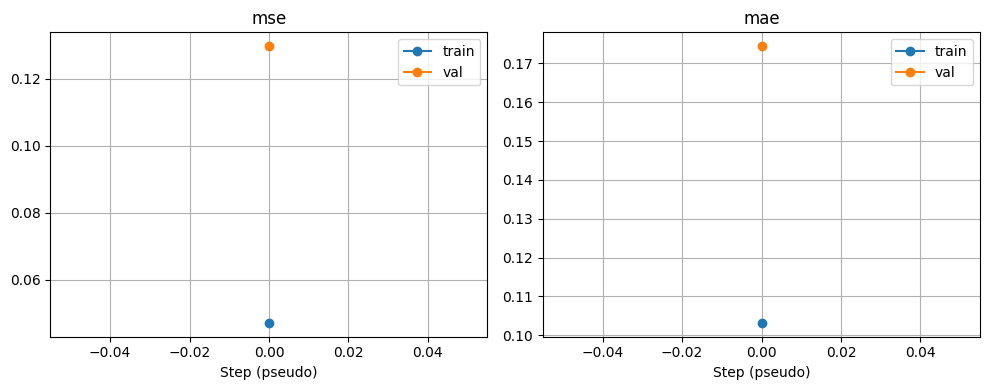

I0000 00:00:1777201457.791172    9102 service.cc:148] XLA service 0x7eb754002a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777201457.791304    9102 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2026-04-26 20:04:17.842233: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777201458.034047    9102 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1777201458.944401    9102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



  Mosfet Loss Model
Metric               Train        Val       Test
--------------------------------------------------
loss                0.4181     0.1933     0.2755
compile_metrics     0.2287     0.2382     0.2475


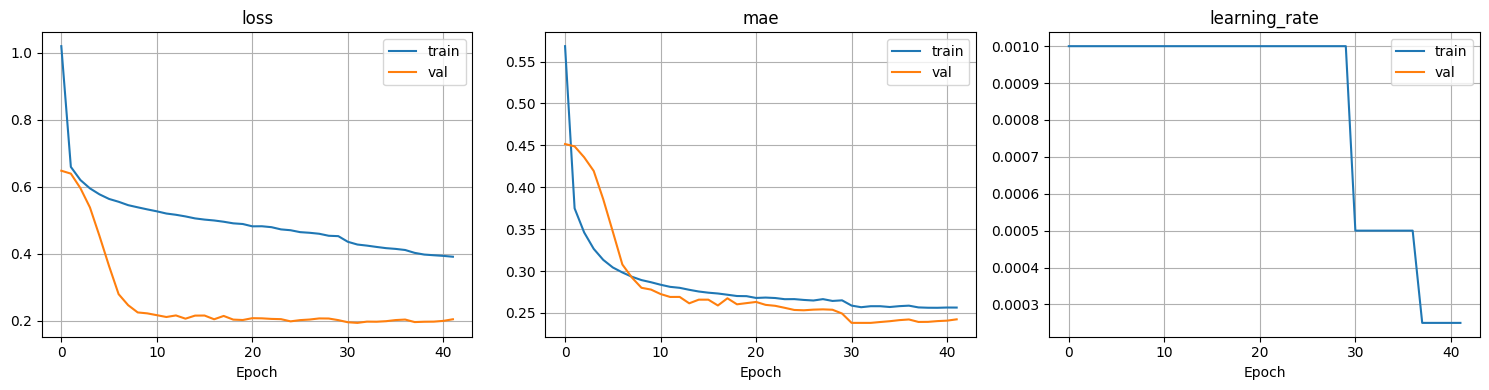


  Diode Loss Model
Metric               Train        Val       Test
--------------------------------------------------
loss                0.0885     0.1290     0.1168
compile_metrics     0.1909     0.2211     0.2171


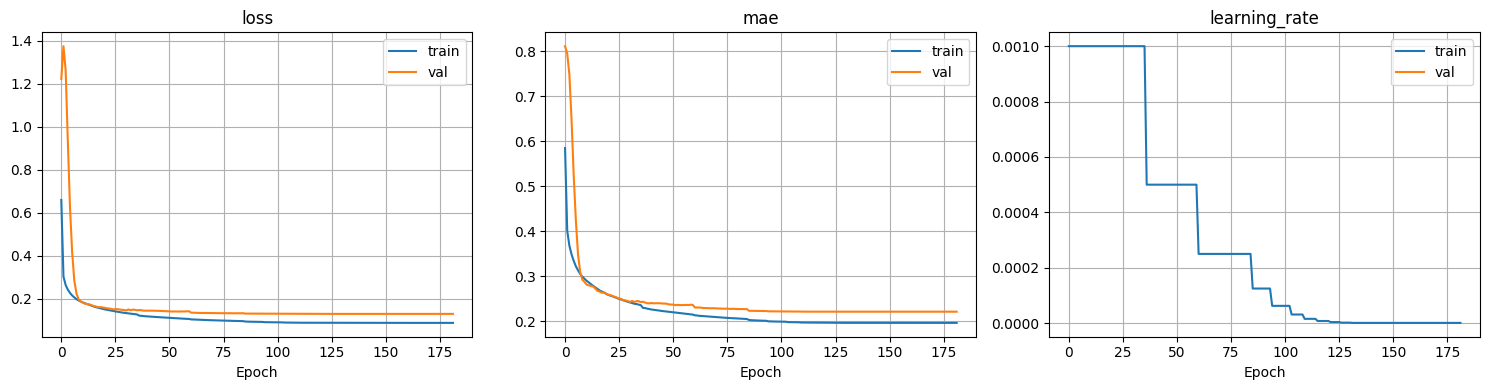


  Leakage Current Model
Metric               Train        Val       Test
--------------------------------------------------
loss                0.2356     0.3649     0.3167
compile_metrics     0.2605     0.3035     0.2932


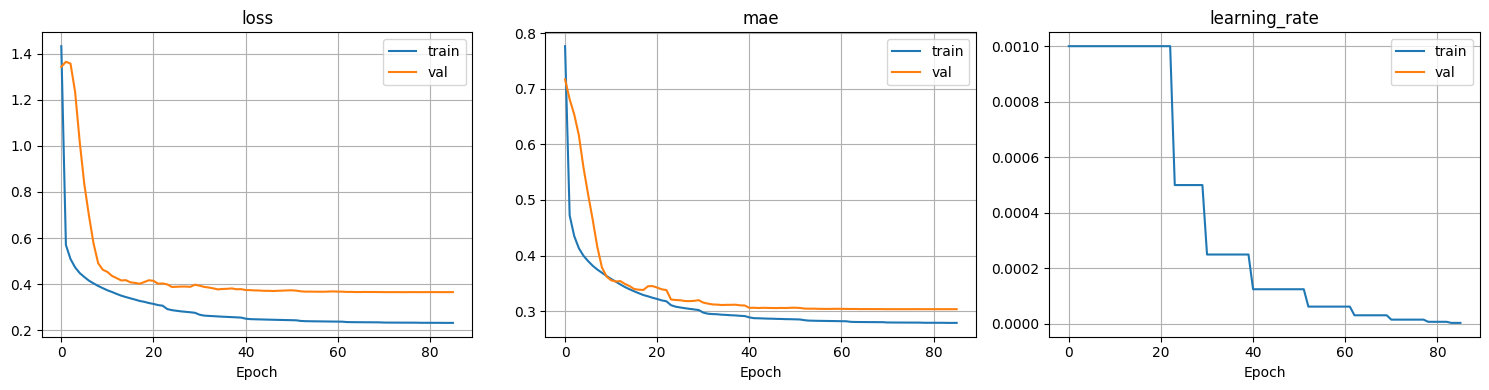


  ESR Loss Model
Metric               Train        Val       Test
--------------------------------------------------
loss                0.0818     0.0972     0.1142
compile_metrics     0.1548     0.1649     0.1683


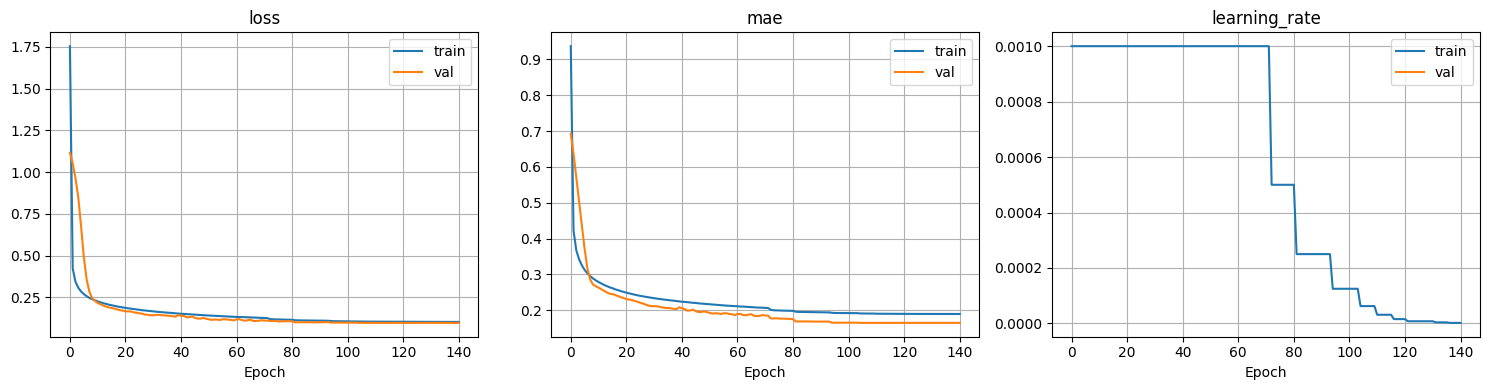

In [7]:

history_ripple = mc.train_and_evaluate_sklearn(
    model_ripple,
    X_train, y_ripple_train,
    X_val,   y_ripple_val,
    X_test,  y_ripple_test,
    model_name='Ripple Model',
)

history_mosfet = mc.train_and_evaluate(
    model_mos_loss,
    X_train, y_mos_loss_train,
    X_val,   y_mos_loss_val,
    X_test,  y_mos_loss_test,
    model_name='Mosfet Loss Model',
    epochs=1000, batch_size=100
)

history_diode = mc.train_and_evaluate(
    model_dio_loss,
    X_train, y_dio_loss_train,
    X_val,   y_dio_loss_val,
    X_test,  y_dio_loss_test,
    model_name='Diode Loss Model',
    epochs=1000, batch_size=100
)

history_leakage = mc.train_and_evaluate(
    model_leakage,
    X_train, y_leakage_train,
    X_val,   y_leakage_val,
    X_test,  y_leakage_test,
    model_name='Leakage Current Model',
    epochs=1000, batch_size=100
)

history_ESR = mc.train_and_evaluate(
    model_ESR_loss,
    X_train, y_ESR_loss_train,
    X_val,   y_ESR_loss_val,
    X_test,  y_ESR_loss_test,
    model_name='ESR Loss Model',
    epochs=1000, batch_size=100
)



# hs

In [8]:
from harmonicSearchtest import *

model_dict ={}
model_dict["ripple"] = model_ripple
model_dict["mos_loss"] = model_mos_loss
model_dict["dio_loss"] = model_dio_loss
model_dict["leakage_current"] = model_leakage
model_dict["ESR_loss"] = model_ESR_loss


scaler_dict = {}

scaler_dict["mm_x"] = x_scaler
scaler_dict["std_ripple"] = y_ripple_scaler
scaler_dict["std_mos_loss"] = y_mos_loss_scaler
scaler_dict["std_dio_loss"] = y_dio_loss_scaler
scaler_dict["std_leakage_current"] = y_leakage_scaler
scaler_dict["std_ESR_loss"] = y_ESR_loss_scaler
scaler_dict["mm_ripple"] = y_ripple_mmscaler

hs_result = harmony_search(model= model_dict,
                           scaler = scaler_dict ,
                           hms = 300,
                           max_iters = 1000,
                           hmcr = 0.7,
                           )

Initialize HM ...
[1 / 1000] best_f = 165.2, best_m={'lripple': np.float64(0.19349037592265406), 'vripple': np.float64(0.1552417971780662), 'mos_cond_loss': np.float32(12.455129), 'mos_sw_loss': np.float32(6.8489623), 'dio_cond_loss': np.float32(52.49746), 'leakage_current': np.float32(0.024013242), 'L1_ESR_loss': np.float32(0.6149232), 'L2_ESR_loss': np.float32(51.661892), 'C1_ESR_loss': np.float32(37.939156), 'C2_ESR_loss': np.float32(2.6976976)}
[2 / 1000] best_f = 165.2, best_m={'lripple': np.float64(0.19349037592265406), 'vripple': np.float64(0.1552417971780662), 'mos_cond_loss': np.float32(12.455129), 'mos_sw_loss': np.float32(6.8489623), 'dio_cond_loss': np.float32(52.49746), 'leakage_current': np.float32(0.024013242), 'L1_ESR_loss': np.float32(0.6149232), 'L2_ESR_loss': np.float32(51.661892), 'C1_ESR_loss': np.float32(37.939156), 'C2_ESR_loss': np.float32(2.6976976)}
[3 / 1000] best_f = 165.2, best_m={'lripple': np.float64(0.19349037592265406), 'vripple': np.float64(0.155241797

In [9]:
def evaluate_to_dict(model, X, y):
    results = model.evaluate(X, y, verbose=0)
    return dict(zip(model.metrics_names, results))

evaluate_to_dict(model_mos_loss, X_test,  y_mos_loss_test)
print(X[100])
# y_mos_loss_scaler.transform(X)
scaled_X = x_scaler.transform(X)
print(scaled_X[100])

y = model_mos_loss.predict(np.asarray([scaled_X[100]]))
print(y)

print(y_mos_loss_scaler.inverse_transform(y))


[4.e-04 1.e-05 9.e-06 9.e-05]
[0.         0.         0.88888889 0.44444444]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[-0.07801669 -2.3997054 ]]
[[28.415972  5.935666]]


In [10]:
# print(model_mos_loss.predict(np.array([[0.0008398530498772605, 0.00011598542992465022, 1e-05, 4.728660689028364e-05]])))

# print(y_mos_loss_scaler.inverse_transform(model_mos_loss.predict(np.array([[0.0008398530498772605, 0.00011598542992465022, 1e-05, 4.728660689028364e-05]]))))

print(y_mos_loss_scaler.mean_)
print(y_mos_loss_scaler.scale_)

print(y_mos_loss[:20])
print(y_mos_loss_train[:5])


[41.1842071  11.06721207]
[163.66029742   2.13840658]
[[ 112.39702643    7.3255439 ]
 [  39.59729578    6.2267352 ]
 [1598.66064572    9.06480435]
 [1153.56557434   11.72109017]
 [ 225.46786483   11.29678702]
 [ 106.51917019   11.31123028]
 [  63.117702     10.17726605]
 [  33.32282395    7.34985547]
 [  67.74779608    6.51065946]
 [  56.03560607    7.44789274]
 [  50.70397396    8.10052316]
 [  83.10596827    8.28210704]
 [  99.84371166    8.60084227]
 [ 156.05235087    9.60229564]
 [ 229.22462009   10.28794506]
 [ 200.87149968   11.14345213]
 [ 106.32351272   11.21940511]
 [  64.35122694   10.50507786]
 [ 112.39702643    7.3255439 ]
 [  39.59729578    6.2267352 ]]
[[-0.12603846  0.49974879]
 [-0.10348708 -0.30633885]
 [ 0.03329066  0.48706938]
 [-0.14752503  0.02582091]
 [-0.16592122  0.14734743]]


# Ga

In [11]:
# import numpy as np

# def fitness_func(ga_instance, solution, solution_idx):

#     x_dict = {
#         "L1": solution[0],
#         "L2": solution[1],
#         "C": solution[2],
#         "fsw": solution[3],
#     }

#     # 🔹 모델 예측
#     metrics = evaluate_lt(model = model_dict,
#                           scaler = scaler_dict, 
#                           x = x_dict)

#     lr = metrics["lripple"]
#     vr = metrics["vripple"]
#     cond_loss = metrics["cond_loss"]
#     sw_loss = metrics["sw_loss"]
#     temp = metrics["temp"]


#     penalty_term = (
#         1e7 * (min(0, lr)**2) +
#         1e7 * (min(0, vr)**2)
#         )

#     lr = max(0.0, lr)
#     vr = max(0.0, vr)

#     ripple = np.array([[lr, vr]])
#     ripple_norm = y_ripple_mmscaler.transform(ripple)

#     i = ripple_norm[0, 0]
#     v = ripple_norm[0, 1]

#     p = 6
#     cost = cond_loss + sw_loss + temp + (v**p + i**p )**(1/p)

#     # penalty 포함
#     cost = cost + penalty_term

#     return -cost   # GA는 maximize라서 음수

In [12]:
# !pip install pygad

In [13]:
# import pygad
# ga_instance = pygad.GA(
#     num_generations = 100, # 세대 진화 횟수(iter)
#     num_parents_mating = 3, # 한 세대에서 n개의 조합을 부모로 선택
#     sol_per_pop = 20, # 한 세대 조합 후보 개수
#     num_genes = 4, # 입력 변수 개수

#     fitness_func = fitness_func,

#     gene_space = [
#         {'low': 1e-4, 'high': 1e-3},        # L1
#         {'low': 1e-5, 'high': 4.6e-4},     # L2
#         {'low': 1e-5, 'high': 4.6e-4},     # C
#         {'low': 5e4, 'high': 10.5e4},       # fsw
#     ],
#     mutation_type = "random",
#     mutation_num_genes = 2,
#     mutation_probability = 0.3,
# )

# ga_instance.run()

# solution, solution_fitness, _ = ga_instance.best_solution()

In [14]:
print(f"HS_result : {hs_result}")


# print("\n\nGA_result:")
# print("L1 =", solution[0])
# print("L2   =", solution[1])
# print("C   =", solution[2])
# print("fsw   =", solution[3])
# print("Predicted Cost =", -solution_fitness)

HS_result : ({'L1': 0.0009009583160279465, 'L2': 1.2999043038612349e-05, 'C1': 9.679045784298934e-06, 'C2': 0.00018842988302287104}, {'lripple': np.float64(0.19724180334639163), 'vripple': np.float64(0.051134002929807076), 'mos_cond_loss': np.float32(-9.427175), 'mos_sw_loss': np.float32(4.753206), 'dio_cond_loss': np.float32(52.37933), 'leakage_current': np.float32(0.02400252), 'L1_ESR_loss': np.float32(-6.3900666), 'L2_ESR_loss': np.float32(33.080776), 'C1_ESR_loss': np.float32(27.481253), 'C2_ESR_loss': np.float32(1.9388578)}, np.float32(103.81618), [np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.22967027242092), np.float64(165.229670272

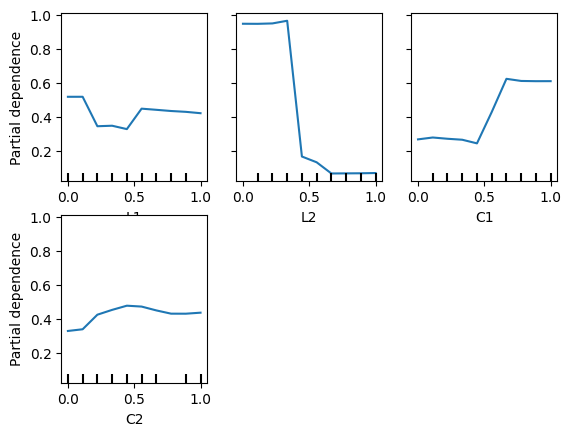

In [15]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = [0, 1, 2, 3]

PartialDependenceDisplay.from_estimator(
    model_ripple,
    X_train,
    features=features,
    feature_names=["L1", "L2", "C1", "C2"]
)

plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# prediction
y_pred_scaled = model_ripple.predict(X_test)

y_pred = y_ripple_scaler.inverse_transform(y_pred_scaled)
y_true = y_ripple_scaler.inverse_transform(y_ripple_test)

# sample-wise error
errors = np.mean((y_true - y_pred)**2, axis=1)

L1 = X_test[:, 0]
L2 = X_test[:, 1]
C1 = X_test[:, 2]
C2  = X_test[:, 3]

def plot_heatmap(x, y, z, xlabel, ylabel, title, bins=20):

    x_bins = np.linspace(x.min(), x.max(), bins)
    y_bins = np.linspace(y.min(), y.max(), bins)

    heatmap = np.zeros((bins-1, bins-1))
    count = np.zeros((bins-1, bins-1))

    for i in range(len(x)):
        xi = np.digitize(x[i], x_bins) - 1
        yi = np.digitize(y[i], y_bins) - 1

        if 0 <= xi < bins-1 and 0 <= yi < bins-1:
            heatmap[yi, xi] += z[i]
            count[yi, xi] += 1

    # 평균 error
    heatmap = np.divide(heatmap, count, where=count != 0)

    plt.figure(figsize=(7,6))
    plt.imshow(heatmap, origin='lower', aspect='auto',
               extent=[x.min(), x.max(), y.min(), y.max()])
    plt.colorbar(label='MSE')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


plot_heatmap(
    L1, L2, errors,
    xlabel="L1",
    ylabel="L2",
    title="Test Error Heatmap (L1 vs L2)"
)

plot_heatmap(
    L1, C1, errors,
    xlabel="L1",
    ylabel="C1",
    title="Test Error Heatmap (L1 vs C1)"
)


plot_heatmap(
    L2, C2, errors,
    xlabel="L2",
    ylabel="C2",
    title="Test Error Heatmap (L2 vs C2)"
)

plot_heatmap(
    L1, C2, errors,
    xlabel="L2",
    ylabel="C2",
    title="Test Error Heatmap (L2 vs C2)"
)

NameError: name 'model_ripple' is not defined